In [1]:
import pandas as pd
final = pd.read_csv("jupyter_output/candidates_with_literature.csv")
print(final.columns.tolist())

['gene', 'compound', 'pubchem_cid', 'MolecularWeight', 'XLogP', 'TPSA', 'HBondDonorCount', 'HBondAcceptorCount', 'SMILES', 'rough_ro5_pass', 'rough_bbb_candidate', 'inchikey', 'dc_status', 'dc_struct_id', 'dc_name', 'atc_code', 'is_approved_drug', 'ad_evidence', 'ad_hits', 'total_hits', 'note', 'pmids']


# Composite scoring

In [2]:
df = pd.read_csv("jupyter_output/candidates_with_literature.csv").copy()

#STRING score per target
string_map = {"NR1H2 gene": 0.991, "NR1H3 gene": 0.967, "TYROBP gene": 0.999}
df["string_norm"] = df["gene"].map(string_map)  # already 0-1

#so each layer -> 0 or 1 (balanced weighting)
df["s_ro5"]    = df["rough_ro5_pass"].astype(int)
df["s_bbb"]    = df["rough_bbb_candidate"].astype(int)
df["s_drug"]   = df["is_approved_drug"].fillna(False).astype(int)
df["s_lit"]    = df["ad_evidence"].map({"Yes": 1, "Unclear": 0.5, "No": 0}).fillna(0)
df["s_string"] = df["string_norm"]  # 0-1 continuous

# composite = sum of 5 layers (max 5)
df["composite_score"] = df[["s_ro5", "s_bbb", "s_drug", "s_lit", "s_string"]].sum(axis=1)

ranked = df.sort_values("composite_score", ascending=False).drop_duplicates(subset=["compound"])
ranked.to_csv("jupyter_output/final_ranked_candidates.csv", index=False)
ranked[["gene", "compound", "composite_score", "s_ro5", "s_bbb", "s_drug", "s_lit", "s_string"]].head(20)

,gene,compound,composite_score,s_ro5,s_bbb,s_drug,s_lit,s_string
56,TYROBP gene,Suvorexant,4.999,1,1,1,1.0,0.999
53,TYROBP gene,Bromperidol,4.999,1,1,1,1.0,0.999
14,NR1H2 gene,Naproxen,4.991,1,1,1,1.0,0.991
11,NR1H2 gene,Lisuride,4.991,1,1,1,1.0,0.991
22,NR1H2 gene,prednisone,4.991,1,1,1,1.0,0.991
17,NR1H2 gene,amitriptyline,4.991,1,1,1,1.0,0.991
23,NR1H2 gene,spironolactone,4.991,1,1,1,1.0,0.991
24,NR1H2 gene,tretinoin,4.991,1,1,1,1.0,0.991
13,NR1H2 gene,Naltrexone,4.991,1,1,1,1.0,0.991
12,NR1H2 gene,Mianserin,4.991,1,1,1,1.0,0.991


# Impotant figures

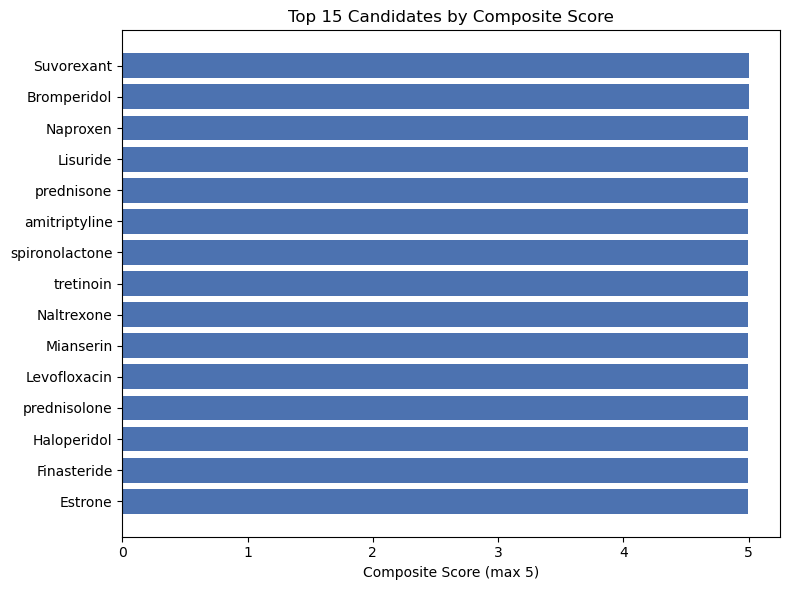

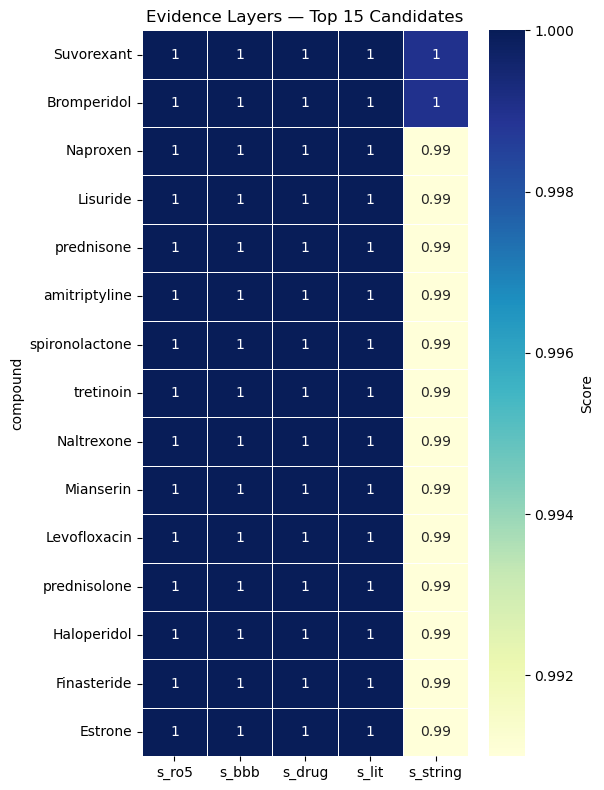

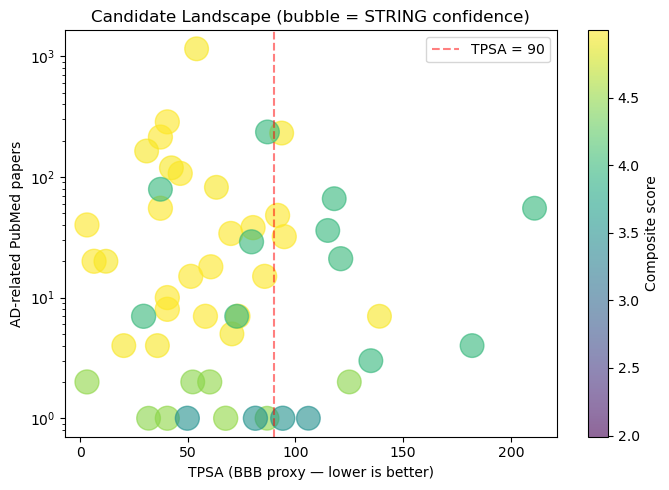

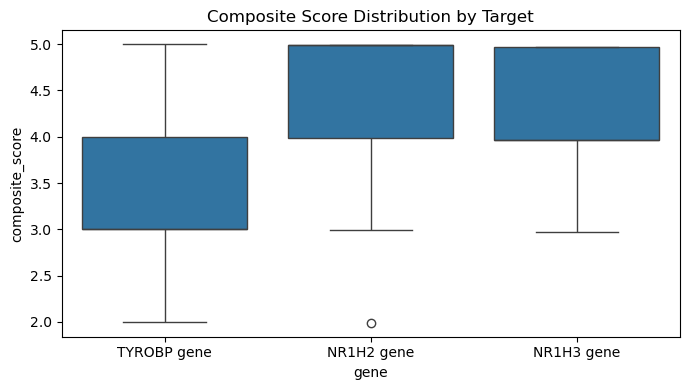

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

top = ranked.head(15)

#fig 1: ranked horizontal bar
plt.figure(figsize=(8, 6))
plt.barh(top["compound"][::-1], top["composite_score"][::-1], color="#4c72b0")
plt.xlabel("Composite Score (max 5)")
plt.title("Top 15 Candidates by Composite Score")
plt.tight_layout(); plt.savefig("jupyter_output/fig_ranked_bar.png", dpi=150); plt.show()

#fig 2: evidence heatmap (compounds x layers)
layers = ["s_ro5", "s_bbb", "s_drug", "s_lit", "s_string"]
plt.figure(figsize=(6, 8))
sns.heatmap(top.set_index("compound")[layers], annot=True, cmap="YlGnBu",
            cbar_kws={"label": "Score"}, linewidths=0.5)
plt.title("Evidence Layers — Top 15 Candidates")
plt.tight_layout(); plt.savefig("jupyter_output/fig_evidence_heatmap.png", dpi=150); plt.show()

#fig 3: bubble plot (BBB vs literature, sized by STRING)
'''plt.figure(figsize=(7, 5))
plt.scatter(ranked["s_bbb"], ranked["s_lit"], s=ranked["s_string"]*300,
            alpha=0.5, c=ranked["composite_score"], cmap="viridis")
plt.colorbar(label="Composite score")
plt.xlabel("BBB candidate (0/1)"); plt.ylabel("AD literature (0/0.5/1)")
plt.title("Candidate Landscape (bubble = STRING confidence)")
plt.tight_layout(); plt.savefig("jupyter_output/fig_bubble.png", dpi=150); plt.show()
'''
plt.figure(figsize=(7, 5))
plt.scatter(ranked["TPSA"], ranked["ad_hits"], 
            s=ranked["s_string"]*300, alpha=0.6,
            c=ranked["composite_score"], cmap="viridis")
plt.colorbar(label="Composite score")
plt.xlabel("TPSA (BBB proxy — lower is better)")
plt.ylabel("AD-related PubMed papers")
plt.yscale("log")
plt.title("Candidate Landscape (bubble = STRING confidence)")
plt.axvline(90, ls="--", c="red", alpha=0.5, label="TPSA = 90")
plt.legend()
plt.tight_layout(); plt.savefig("jupyter_output/fig_bubble.png", dpi=150); plt.show()


#fig 4: count by target + score
plt.figure(figsize=(7, 4))
sns.boxplot(data=ranked, x="gene", y="composite_score")
plt.title("Composite Score Distribution by Target")
plt.tight_layout(); plt.savefig("jupyter_output/fig_score_by_target.png", dpi=150); plt.show()

# ML classifier. t

CV accuracy: 0.653 (proof-of-concept only)


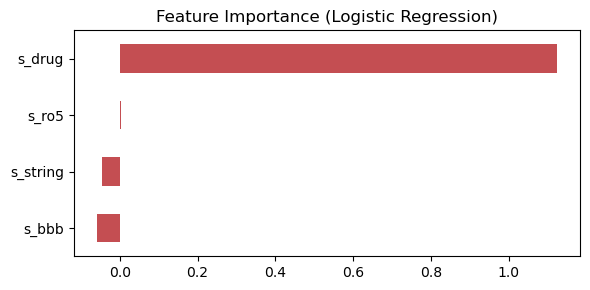

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

#label: "AD-relevant" = literature Yes
df["label"] = (df["ad_evidence"] == "Yes").astype(int)

features = ["s_ro5", "s_bbb", "s_drug", "s_string"] # NOT s_lit
X = df[features].fillna(0)
y = df["label"]

if y.sum() >= 5:  # need enough positives
    clf = LogisticRegression(max_iter=1000)
    scores = cross_val_score(clf, X, y, cv=3)
    print("CV accuracy:", scores.mean().round(3), "(proof-of-concept only)")

    clf.fit(X, y)
    importance = pd.Series(clf.coef_[0], index=features).sort_values()
    importance.plot(kind="barh", figsize=(6, 3), color="#c44e52")
    plt.title("Feature Importance (Logistic Regression)")
    plt.tight_layout(); plt.savefig("jupyter_output/fig_feature_importance.png", dpi=150); plt.show()
else:
    print("Too few positives for a meaningful classifier — report as limitation.")

# 3d structure figures

In [1]:
#3D structures of top candidates
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
import pandas as pd
import os

ranked = pd.read_csv("jupyter_output/final_ranked_candidates.csv")
top = ranked.head(6)  # top 6 for the poster

os.makedirs("jupyter_output/structures_3d", exist_ok=True)

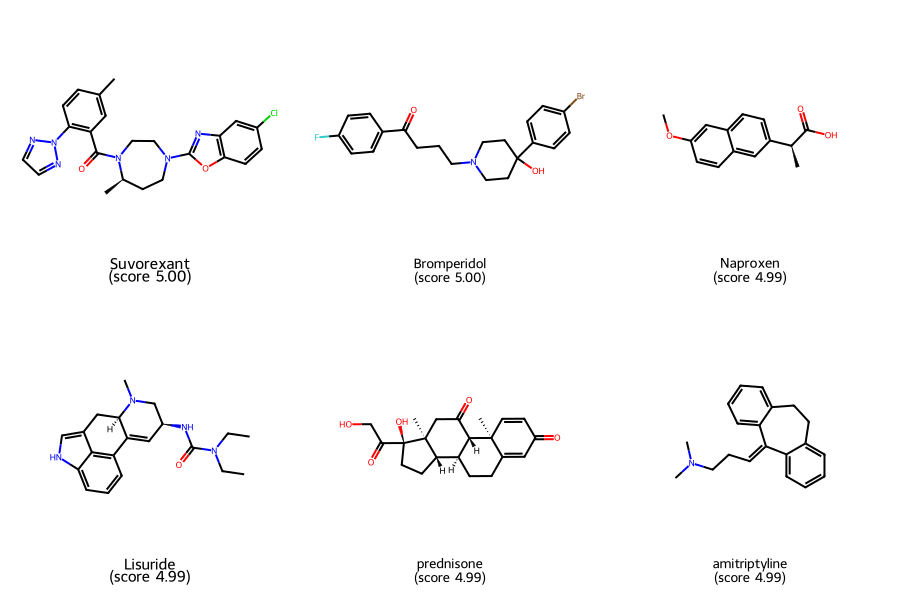

In [2]:
mols, names = [], []
for row in top.itertuples():
    m = Chem.MolFromSmiles(row.SMILES)
    if m:
        mols.append(m)
        names.append(f"{row.compound}\n(score {row.composite_score:.2f})")

img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300, 300), legends=names,
                          useSVG=False, returnPNG=False)
img.save("jupyter_output/fig_top_structures_2d.png")
img

In [3]:
# pip install py3Dmol
import py3Dmol

def show_3d(smiles, name):
    m = Chem.MolFromSmiles(smiles)
    m = Chem.AddHs(m)
    AllChem.EmbedMolecule(m, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(m)
    mb = Chem.MolToMolBlock(m)

    view = py3Dmol.view(width=400, height=350)
    view.addModel(mb, "mol")
    view.setStyle({"stick": {}, "sphere": {"scale": 0.3}})
    view.setBackgroundColor("white")
    view.zoomTo()
    print(name)
    return view.show()

#top candidate
row = top.iloc[0]
show_3d(row["SMILES"], row["compound"])

Suvorexant


3Dmol.js failed to load for some reason. Please check your browser console for error messages.